In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import csv
import torch
import numpy as np
from matplotlib import pyplot as plt
from collections import OrderedDict

import utils_data

In [2]:
def load_m4_file(filepath):
    series = OrderedDict()  # preserves order

    with open(filepath, 'r') as f:
        reader = csv.reader(f)
        first = True
        for row in reader:
            if not row:
                continue
            if first:
                first = False
                continue
            series_id = row[0]
            values = [float(v) for v in row[1:] if v != '']
            series[series_id] = values

    return series

def remove_mean(timeseries, dim=0):
    """Removes mean from ``timeseries`` in dimension ``dim``. Dimensions are preserved."""
    return timeseries - torch.mean(timeseries, dim, keepdim=True)

def scale_timeseries(timeseries, dim=0):
    scaler = utils_data.minmax_scaler(feature_range=(-1, 1))
    return scaler.fit_transform(timeseries, dim=dim)

def filter_data(model, data):

    window_nsample   = model.lookback_nsample + model.forecast_nsample

    if data.shape[1] < window_nsample:
        print('err >> data length is less than a prediction window!')
        return

    data_start = 0
    data_end   = data.shape[1] - window_nsample

    stat = []
    trans = []

    for j in range(data_start, data_end):
        window_start = j
        window_end   = window_start + window_nsample
        window       = data[:, window_start:window_end]

        for timeseries in window:
            timeseries, is_stat = utils_data.label_timeseries(scale_timeseries(remove_mean(timeseries)), model)

            if is_stat:
                stat.append(timeseries)
            else:
                trans.append(timeseries)

    stat  = torch.stack(stat, dim=0)
    trans = torch.stack(trans, dim=0)
    return stat, trans

def mix_data(stat, trans):
    size_min = stat.shape[0] if stat.shape[0] < trans.shape[0] else trans.shape[0]

    stat  = stat[:size_min]
    trans = trans[:size_min]

    data_stack = torch.stack([stat, trans], dim=1)
    data_mix   = torch.flatten(data_stack, start_dim=0, end_dim=1)

    return data_mix

In [3]:
dataname = '../../data/baselines/Hourly-train.csv'
data     = load_m4_file(dataname)

(700,)


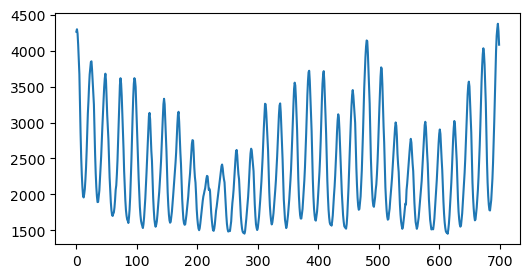

In [4]:
h = np.array(data['H5'])
print(h.shape)

plt.figure(figsize=(6,3))
plt.plot(h[:])
plt.show()

In [5]:
timeseries_nsample_min = 700

data_for_train = torch.stack(
    [torch.tensor(value[-timeseries_nsample_min:]).reshape(-1, 1) for key, value in data.items()], dim=0)
print(data_for_train.shape)

torch.Size([414, 700, 1])


In [6]:
# --! load a trained stationary model --!

model = torch.load('../../models/baselines/m4_h_kind_filter.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=48, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=384, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=4, out_features=4, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=8, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=48, bias=True)
          (1): Identity()
        )
      )
    )
    (pre_mean

In [7]:
stat, trans = filter_data(model, data_for_train)

print(f'inf > number of stationary time series is {stat.shape[0]}')
print(f'inf > number of transient time series is {trans.shape[0]}')

mix = mix_data(stat, trans)

print(f'inf > number of mixed time series is {mix.shape[0]}')

inf > number of stationary time series is 71915
inf > number of transient time series is 158269
inf > number of mixed time series is 143830


In [8]:
datasaved = True

if datasaved:
    savedir = '../../data/baselines/m4_train_stat'
    utils_data.write_datafile(f'{savedir}/train1', stat)

    savedir = '../../data/baselines/m4_train_trans'
    utils_data.write_datafile(f'{savedir}/train1', trans)

    savedir = '../../data/baselines/m4_train_mixed'
    utils_data.write_datafile(f'{savedir}/train1', mix)

In [9]:
dataname = '../../data/baselines/Hourly-test.csv'
data     = load_m4_file(dataname)

(48,)


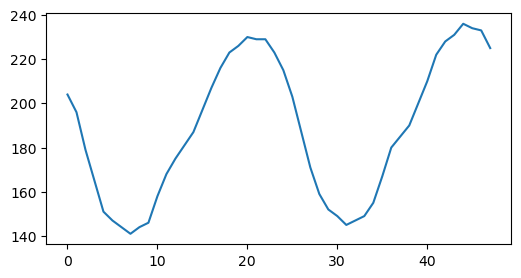

In [10]:
h = np.array(data['H14'])
print(h.shape)

plt.figure(figsize=(6,3))
plt.plot(h[:])
plt.show()

torch.Size([144, 1])


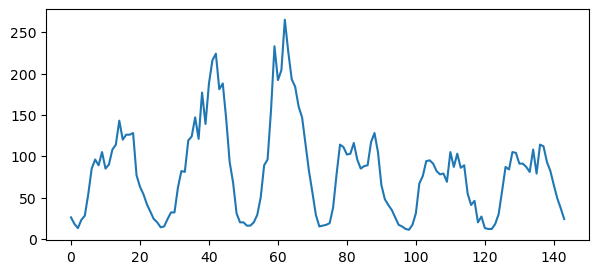

In [11]:
forecast_nsample = model.forecast_nsample
lookback_nsample = model.lookback_nsample

# --! format test data
data_for_test = [torch.tensor(value).reshape(-1, 1) for key, value in data.items()]
data_for_test = [torch.cat(
    [train[-lookback_nsample:], test[:forecast_nsample]], dim=0) for train, test in zip(data_for_train, data_for_test)]

print(data_for_test[0].shape)

plt.figure(figsize=(7, 3))
plt.plot(data_for_test[413])
plt.show()

datasaved = True

if datasaved:
    savedir  = '../../data/baselines/m4_test'
    filename = 'eval'
    savedata = torch.stack(data_for_test, dim=0)
    utils_data.write_datafile(f'{savedir}/{filename}', savedata)